# **1. Import Required Libraries**


In [6]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# **2. Load Data, Model & Scaler**

In [15]:
# Load dataset
df = pd.read_csv("data/processed_nvidia.csv", index_col="Date", parse_dates=True)

X = df.drop(columns=["Target"])
y = df["Target"]

# Train-test split (same as training)
train_size = int(len(df) * 0.9)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Load trained model and scaler
with open("notebooks/xGboost_mdoel.pk1", "rb") as f:
    model = pickle.load(f)

with open("notebooks/scaler.pk1", "rb") as f:
    scaler = pickle.load(f)

X_test_scaled = scaler.transform(X_test)
y_pred = model.predict(X_test_scaled)


In [14]:
from sklearn.exceptions import InconsistentVersionWarning
import warnings

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)


# **Model Visualization**


# **1. Actual vs Predicted Plot**

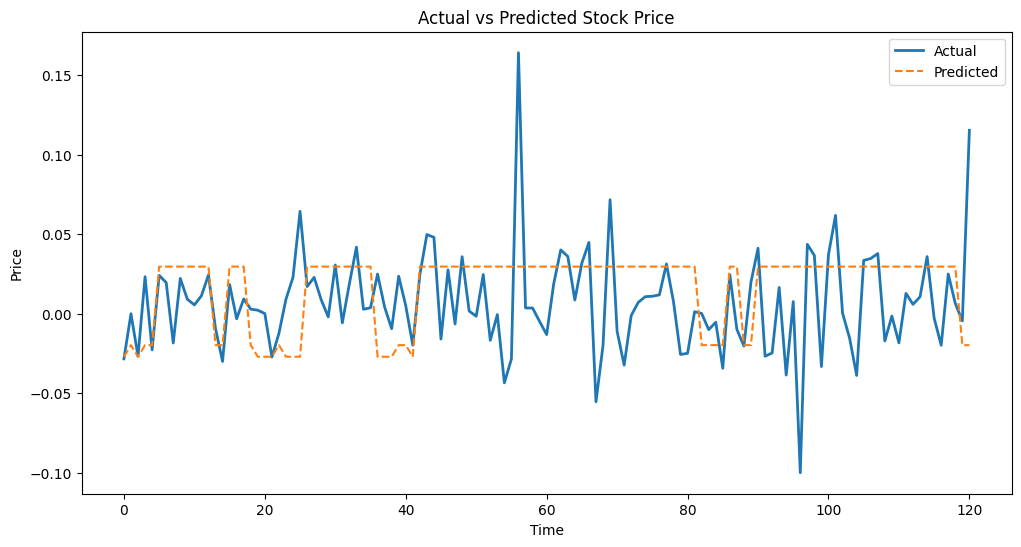

In [16]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle="--")
plt.title("Actual vs Predicted Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()


# **2. Residuals (Error) Distribution**

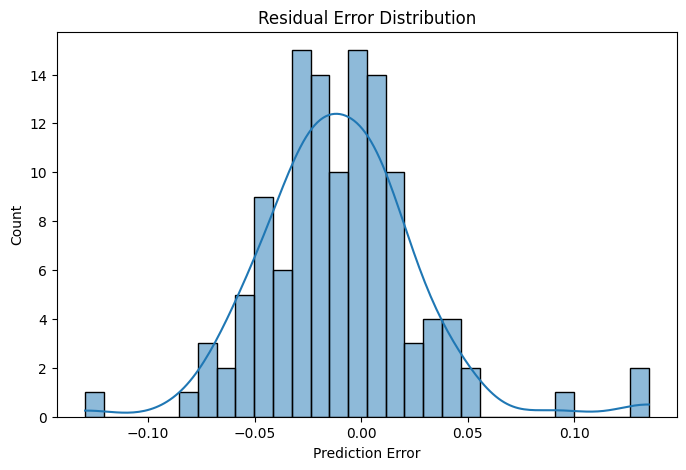

In [17]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Error Distribution")
plt.xlabel("Prediction Error")
plt.show()


# **3. Feature Importance Visualization**

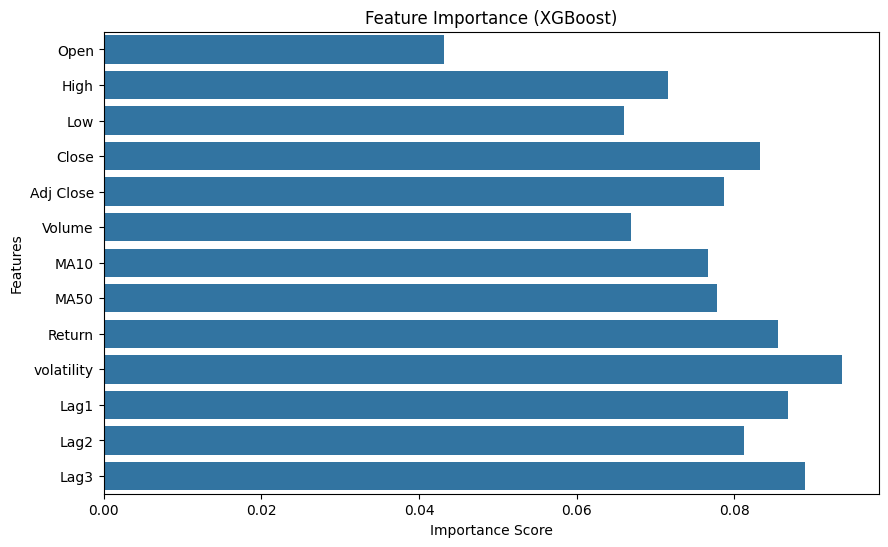

In [18]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


# **4. Error Metrics Visualization**

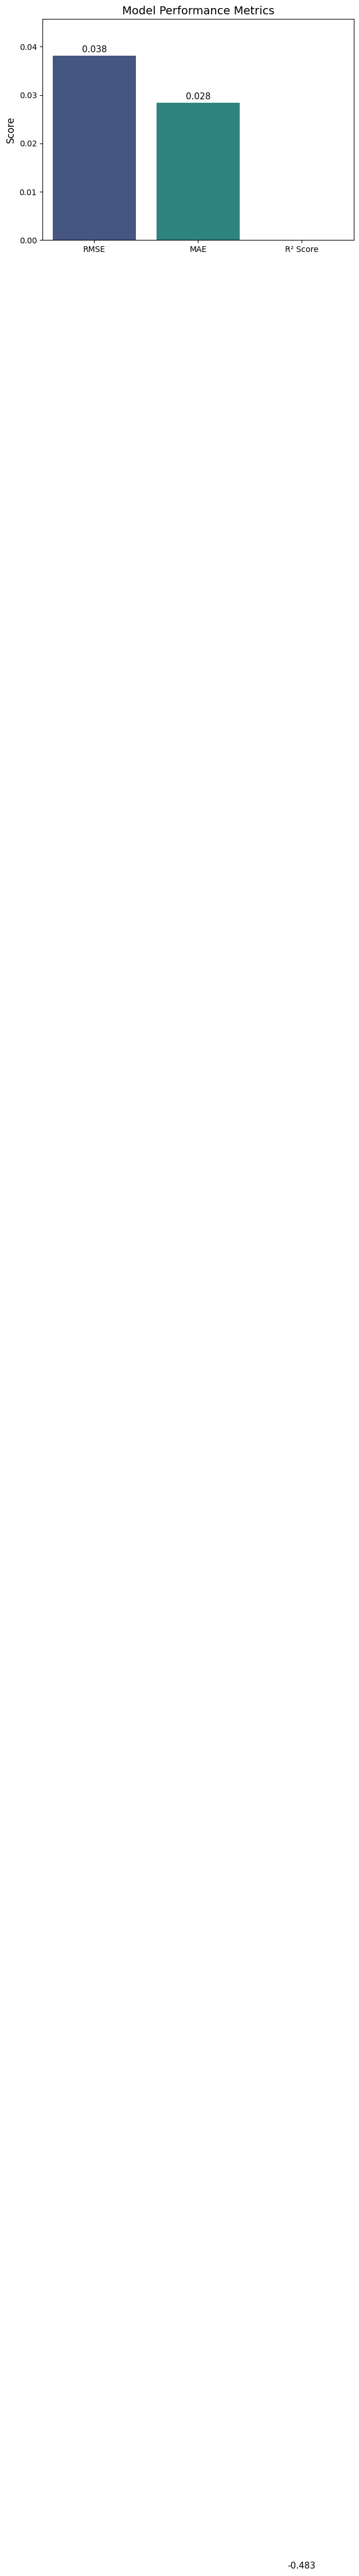

In [22]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create DataFrame
metrics = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R² Score"],
    "Value": [rmse, mae, r2]
})

# Plot
plt.figure(figsize=(7,5))
bars = sns.barplot(
    x="Metric", y="Value", data=metrics, 
    hue="Metric", dodge=False, palette="viridis", legend=False
)
plt.title("Model Performance Metrics", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("")
plt.ylim(0, max(metrics["Value"])*1.2)

# Annotate values on top of bars
for i, v in enumerate(metrics["Value"]):
    plt.text(i, v + 0.02*max(metrics["Value"]), f"{v:.3f}", ha='center', fontsize=11)

plt.show()

# **5. Prediction Error Scatter Plot**

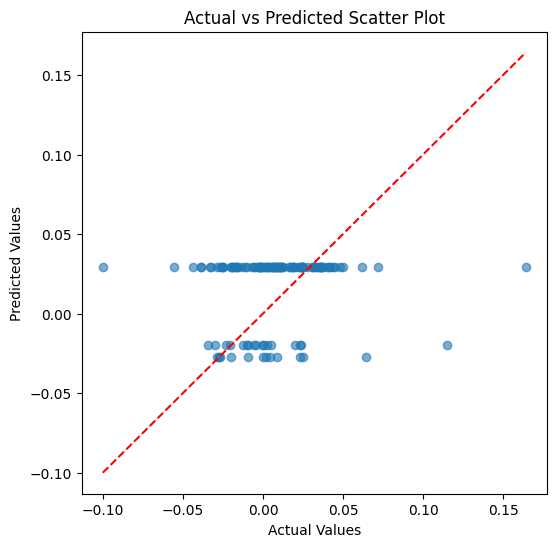

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter Plot")
plt.show()


# **